# Fair odds and closing lines with the Odds-API.io v3 REST API

Every bookmaker price contains a margin (the "vig" or overround), so the implied probabilities of a market add up to more than 100% and you have to strip that margin out ("devig") before the numbers mean anything. The closing line, the last price before kickoff, is the most informed price a market produces, and beating it consistently (positive closing line value, CLV) is the standard test of whether a betting model has an edge. This notebook pulls a real snapshot of football moneyline and spread prices from six bookmakers, devigs them with two methods, prices each soft book against a sharp consensus line, and finishes with a closing-line and line-movement example from the historical endpoints.

In [1]:
# Requirements: pip install requests pandas matplotlib
# Optional: export ODDS_API_KEY=...   (without it the notebook uses the frozen snapshot in data/)
import json
import math
import os
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests

BASE = "https://api.odds-api.io/v3"
API_KEY = os.environ.get("ODDS_API_KEY")
SNAPSHOT = Path("data/snapshot-2026-09-19.json")

BOOKMAKERS = ["Bet365", "Unibet", "SingBet", "ON Sharp", "1xbet", "Betfair Sportsbook"]
SHARP = "ON Sharp"
MARKETS = {"ML", "Spread"}
LEAGUES = ["england-premier-league", "spain-laliga", "germany-bundesliga", "italy-serie-a", "france-ligue-1"]

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)


def api_get(path, **params):
    params["apiKey"] = API_KEY
    r = requests.get(f"{BASE}{path}", params=params, timeout=30)
    if r.status_code != 200:
        raise requests.HTTPError(f"{r.status_code} {path}: {r.text[:200]}")
    return r.json()

## 1. Data

With `ODDS_API_KEY` set, the cell below makes nine requests: one `/events` call per league to pick the next big fixtures, one `/odds/multi` call for all of them (max 10 event ids per call), one `/historical/closing-lines` call for the last seven days of Premier League moneylines, and two `/odds/movements` calls for the fixture closest to kickoff. Only the `ML` and `Spread` markets are kept. Without a key, or if any call fails (the closing-lines endpoint is paid-plan only, and the free tier limits how many bookmakers a key can request), it loads the frozen snapshot captured on 18 September 2026 so every cell still runs.

In [2]:
def fetch_live():
    now = datetime.now(timezone.utc)
    picked = []
    for league in LEAGUES:
        events = api_get("/events", sport="football", league=league, status="pending", limit=10)
        events = [e for e in events if e.get("status") == "pending"]
        events.sort(key=lambda e: e["date"])
        picked.extend(events[:2])
    picked = picked[:10]

    odds = api_get("/odds/multi", eventIds=",".join(str(e["id"]) for e in picked), bookmakers=",".join(BOOKMAKERS))
    for ev in odds:
        ev["bookmakers"] = {
            b: [m for m in ms if m["name"] in MARKETS]
            for b, ms in ev.get("bookmakers", {}).items() if b in BOOKMAKERS
        }

    closing = None
    closing_error = None
    try:
        closing = api_get("/historical/closing-lines", sport="football", leagues="england-premier-league",
                          **{"from": (now - pd.Timedelta(days=7)).strftime("%Y-%m-%dT00:00:00Z"),
                             "to": now.strftime("%Y-%m-%dT%H:%M:%SZ")},
                          markets="ML", bookmakers="Bet365,ON Sharp", limit=100)
    except requests.HTTPError as exc:
        closing_error = str(exc)

    soonest = min(odds, key=lambda e: e["date"])
    movements = {"eventId": soonest["id"], "home": soonest["home"], "away": soonest["away"], "kickoff": soonest["date"]}
    for b in ["Bet365", SHARP]:
        movements[b] = api_get("/odds/movements", eventId=soonest["id"], bookmaker=b, market="ML")

    return {"capturedAt": now.isoformat(timespec="seconds"), "source": "live", "events": odds,
            "closingLines": closing, "closingLinesError": closing_error, "movements": movements}


if API_KEY:
    try:
        snap = fetch_live()
        if os.environ.get("ODDS_API_SAVE_SNAPSHOT") == "1":
            SNAPSHOT.parent.mkdir(exist_ok=True)
            SNAPSHOT.write_text(json.dumps(snap, indent=1))
    except requests.HTTPError as exc:
        print("Live fetch failed, using the frozen snapshot:", exc)
        snap = json.loads(SNAPSHOT.read_text())
else:
    snap = json.loads(SNAPSHOT.read_text())

print(f"source={snap['source']}  capturedAt={snap['capturedAt']}  events={len(snap['events'])}")
pd.DataFrame([{"id": e["id"], "kickoff": e["date"], "league": e["league"]["name"], "home": e["home"], "away": e["away"],
               "books": len(e["bookmakers"])} for e in snap["events"]])

source=frozen snapshot  capturedAt=2026-09-18T18:59:30+00:00  events=8


,id,kickoff,league,home,away,books
0,72221272,2026-09-20T13:00:00Z,England - Premier League,AFC Bournemouth,Liverpool FC,6
1,72513206,2026-09-20T13:30:00Z,Germany - Bundesliga,Bayer Leverkusen,RB Leipzig,6
2,71945280,2026-09-19T16:00:00Z,Italy - Serie A,AS Roma,Inter Milano,6
3,72036192,2026-09-20T18:45:00Z,France - Ligue 1,Olympique Marseille,Paris Saint-Germain,6
4,72478600,2026-09-19T19:00:00Z,Spain - LaLiga,Sevilla FC,FC Barcelona,6
5,72221276,2026-09-19T14:00:00Z,England - Premier League,Brighton & Hove Albion,Arsenal FC,6
6,72513204,2026-09-19T16:30:00Z,Germany - Bundesliga,VfB Stuttgart,Borussia Dortmund,6
7,72478588,2026-09-20T14:15:00Z,Spain - LaLiga,Atletico Madrid,Real Madrid,6


## 2. Devigging: multiplicative and power

Implied probability is `1 / decimal odds`. Summed over the outcomes of a market it gives the **overround**; the bookmaker margin is `overround - 1`.

* **Multiplicative** (normalise): divide each implied probability by the overround. Simple, but it spreads the margin evenly, which over-shrinks longshots.
* **Power**: find the exponent `k` with `sum(p_i ** k) = 1` and use `p_i ** k`. The margin is removed disproportionately from the longshots, which is closer to how books actually shade prices.

Both take a list of decimal odds and return probabilities that sum to 1.

In [3]:
def implied(odds):
    return [1.0 / o for o in odds]


def devig_multiplicative(odds):
    p = implied(odds)
    s = sum(p)
    return [x / s for x in p]


def devig_power(odds, tol=1e-10):
    p = implied(odds)
    lo, hi = 0.5, 5.0
    for _ in range(200):
        k = (lo + hi) / 2
        total = sum(x ** k for x in p)
        if abs(total - 1) < tol:
            break
        lo, hi = (k, hi) if total > 1 else (lo, k)
    return [x ** k for x in p]


def ml_rows(snapshot):
    rows = []
    for ev in snapshot["events"]:
        label = f"{ev['home']} v {ev['away']}"
        for book, markets in ev["bookmakers"].items():
            for m in markets:
                if m["name"] != "ML":
                    continue
                o = m["odds"][0]
                odds = [float(o["home"]), float(o["draw"]), float(o["away"])]
                rows.append({"event": label, "bookmaker": book, "market": "ML", "line": None,
                             "home": odds[0], "draw": odds[1], "away": odds[2],
                             "overround": sum(implied(odds)), "updatedAt": m["updatedAt"]})
    return pd.DataFrame(rows)


def spread_rows(snapshot):
    rows = []
    for ev in snapshot["events"]:
        label = f"{ev['home']} v {ev['away']}"
        for book, markets in ev["bookmakers"].items():
            for m in markets:
                if m["name"] != "Spread":
                    continue
                for o in m["odds"]:
                    odds = [float(o["home"]), float(o["away"])]
                    rows.append({"event": label, "bookmaker": book, "market": "Spread", "line": float(o["hdp"]),
                                 "home": odds[0], "draw": None, "away": odds[1],
                                 "overround": sum(implied(odds)), "updatedAt": m["updatedAt"]})
    return pd.DataFrame(rows)


ml = ml_rows(snap)
spread = spread_rows(snap)

# main spread line per book and event: the handicap where the two prices are closest
main_spread = (spread.assign(gap=(spread["home"] - spread["away"]).abs())
               .sort_values("gap").groupby(["event", "bookmaker"], as_index=False).first().drop(columns="gap"))

margin_ml = ml.pivot(index="event", columns="bookmaker", values="overround").sub(1).mul(100).round(2)
margin_ml.loc["mean"] = margin_ml.mean().round(2)
print("Moneyline margin, % (overround minus 1)")
margin_ml

Moneyline margin, % (overround minus 1)


bookmaker,1xbet,Bet365,Betfair Sportsbook,ON Sharp,SingBet,Unibet
event,,,,,,
AFC Bournemouth v Liverpool FC,1.58,5.09,4.03,2.49,4.12,5.14
AS Roma v Inter Milano,1.55,5.66,4.62,2.50,3.98,7.43
Atletico Madrid v Real Madrid,1.59,5.38,4.70,2.51,4.31,5.83
Bayer Leverkusen v RB Leipzig,1.57,5.86,3.66,2.50,4.22,7.12
Brighton & Hove Albion v Arsenal FC,1.54,5.67,4.46,2.51,4.04,4.80
Olympique Marseille v Paris Saint-Germain,1.58,5.80,5.04,2.50,5.30,6.89
Sevilla FC v FC Barcelona,1.56,6.12,4.36,2.48,4.49,5.06
VfB Stuttgart v Borussia Dortmund,1.55,4.52,4.34,2.50,4.53,7.21
mean,1.57,5.51,4.40,2.50,4.37,6.18


In [4]:
margin_spread = main_spread.pivot(index="event", columns="bookmaker", values="overround").sub(1).mul(100).round(2)
margin_spread.loc["mean"] = margin_spread.mean().round(2)
print("Spread margin at each book's main line, %")
margin_spread

Spread margin at each book's main line, %


bookmaker,1xbet,Bet365,ON Sharp,SingBet,Unibet
event,,,,,
AFC Bournemouth v Liverpool FC,6.98,3.97,2.00,3.23,5.60
AS Roma v Inter Milano,6.64,3.91,2.00,3.14,5.61
Atletico Madrid v Real Madrid,6.92,4.05,2.02,3.14,5.58
Bayer Leverkusen v RB Leipzig,1.53,3.97,1.99,3.23,5.56
Brighton & Hove Albion v Arsenal FC,5.27,3.97,2.02,3.10,5.75
Olympique Marseille v Paris Saint-Germain,1.53,4.05,2.01,3.37,5.34
Sevilla FC v FC Barcelona,6.76,3.97,2.01,3.23,5.75
VfB Stuttgart v Borussia Dortmund,1.51,4.18,1.99,3.71,5.87
mean,4.64,4.01,2.00,3.27,5.63


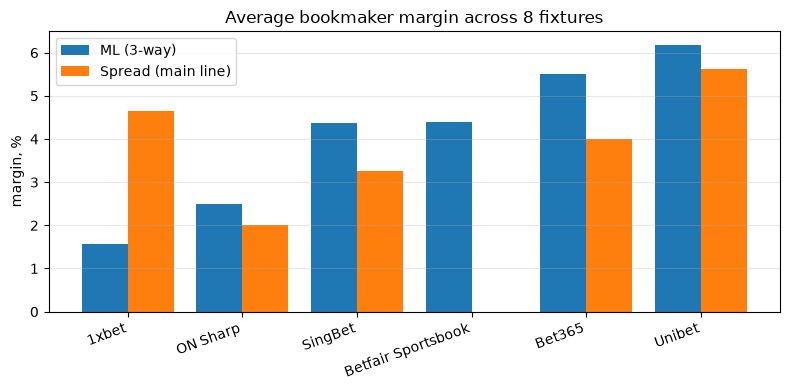

In [5]:
avg = pd.DataFrame({"ML": margin_ml.drop(index="mean").mean(), "Spread": margin_spread.drop(index="mean").mean()}).sort_values("ML")

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(avg))
ax.bar([i - 0.2 for i in x], avg["ML"], width=0.4, label="ML (3-way)")
ax.bar([i + 0.2 for i in x], avg["Spread"], width=0.4, label="Spread (main line)")
ax.set_xticks(list(x))
ax.set_xticklabels(avg.index, rotation=20, ha="right")
ax.set_ylabel("margin, %")
ax.set_title(f"Average bookmaker margin across {margin_ml.shape[0] - 1} fixtures")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Fair probabilities: sharp consensus vs soft books

`ON Sharp` is the sharp consensus feed. Its prices, devigged with the power method, are used as the fair probability for each outcome. For every soft-book price on the same outcome:

```
EV = fair_probability * soft_odds - 1
```

A positive EV means the soft book is offering a better price than the sharp fair line implies. For spreads the comparison is only made where the soft book and the sharp feed quote the same handicap, so the two prices refer to the same bet.

In [6]:
def ev_table(ml, main_spread, spread):
    rows = []
    sharp_ml = ml[ml["bookmaker"] == SHARP].set_index("event")
    sharp_spread = spread[spread["bookmaker"] == SHARP].set_index(["event", "line"])

    for _, r in ml[ml["bookmaker"] != SHARP].iterrows():
        if r["event"] not in sharp_ml.index:
            continue
        s = sharp_ml.loc[r["event"]]
        fair = devig_power([s["home"], s["draw"], s["away"]])
        for side, p in zip(["home", "draw", "away"], fair):
            rows.append({"event": r["event"], "market": "ML", "line": "", "side": side, "bookmaker": r["bookmaker"],
                         "odds": r[side], "fair_prob": p, "fair_odds": 1 / p, "ev_pct": (p * r[side] - 1) * 100})

    for _, r in spread[spread["bookmaker"] != SHARP].iterrows():
        key = (r["event"], r["line"])
        if key not in sharp_spread.index:
            continue
        s = sharp_spread.loc[key]
        fair = devig_power([s["home"], s["away"]])
        for side, p in zip(["home", "away"], fair):
            rows.append({"event": r["event"], "market": "Spread", "line": r["line"], "side": side, "bookmaker": r["bookmaker"],
                         "odds": r[side], "fair_prob": p, "fair_odds": 1 / p, "ev_pct": (p * r[side] - 1) * 100})
    return pd.DataFrame(rows)


ev = ev_table(ml, main_spread, spread)
print(f"{len(ev)} soft-book prices compared against the sharp fair line")
(ev.sort_values("ev_pct", ascending=False)
   .head(15)
   .assign(fair_prob=lambda d: d["fair_prob"].round(4), fair_odds=lambda d: d["fair_odds"].round(3), ev_pct=lambda d: d["ev_pct"].round(2))
   .reset_index(drop=True))

566 soft-book prices compared against the sharp fair line


,event,market,line,side,bookmaker,odds,fair_prob,fair_odds,ev_pct
0,Sevilla FC v FC Barcelona,ML,,away,1xbet,1.250,0.8240,1.214,3.00
1,Olympique Marseille v Paris Saint-Germain,ML,,away,1xbet,1.428,0.7167,1.395,2.34
2,Sevilla FC v FC Barcelona,Spread,2.5,home,1xbet,1.705,0.5972,1.674,1.83
3,AFC Bournemouth v Liverpool FC,Spread,-0.25,away,1xbet,1.538,0.6591,1.517,1.37
4,Brighton & Hove Albion v Arsenal FC,ML,,away,1xbet,1.753,0.5780,1.730,1.33
5,Brighton & Hove Albion v Arsenal FC,Spread,1.5,home,1xbet,1.463,0.6911,1.447,1.10
6,Sevilla FC v FC Barcelona,Spread,2.25,home,1xbet,1.842,0.5488,1.822,1.09
7,Brighton & Hove Albion v Arsenal FC,Spread,1.25,home,1xbet,1.582,0.6389,1.565,1.08
8,Sevilla FC v FC Barcelona,Spread,3.0,home,Unibet,1.370,0.7375,1.356,1.04
9,Sevilla FC v FC Barcelona,ML,,away,Bet365,1.222,0.8240,1.214,0.69


In [7]:
summary = (ev.groupby(["bookmaker", "market"])["ev_pct"]
             .agg(prices="size", mean_ev="mean", best_ev="max", positive=lambda s: (s > 0).sum())
             .round(2))
print("EV of each soft book's prices against the sharp fair line, by market")
summary

EV of each soft book's prices against the sharp fair line, by market


prices  mean_ev  best_ev  positive
bookmaker          market                                    
1xbet              ML          24    -3.81     3.00         5
                   Spread     108    -7.12     1.83         7
Bet365             ML          24    -7.79     0.69         1
                   Spread     144    -6.91     0.05         1
Betfair Sportsbook ML          24    -5.70    -0.61         0
SingBet            ML          24    -6.12    -0.38         0
                   Spread      62    -5.02    -0.05         0
Unibet             ML          24    -7.53    -1.81         0
                   Spread     132    -7.04     1.04         3

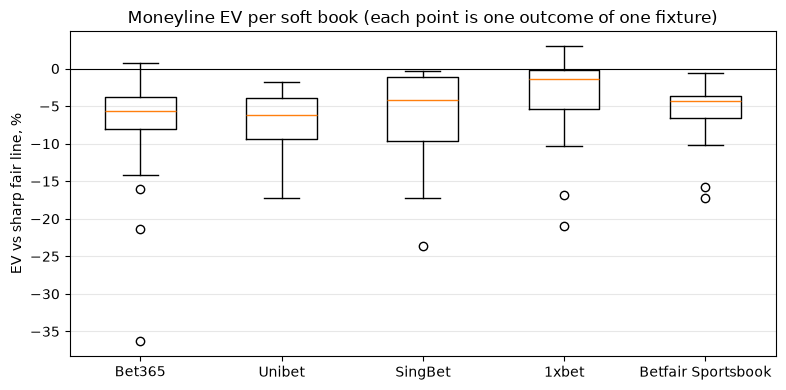

In [8]:
books = [b for b in BOOKMAKERS if b != SHARP and b in set(ev["bookmaker"])]
data = [ev.loc[(ev["bookmaker"] == b) & (ev["market"] == "ML"), "ev_pct"].values for b in books]

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(data, tick_labels=books, showfliers=True)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("EV vs sharp fair line, %")
ax.set_title("Moneyline EV per soft book (each point is one outcome of one fixture)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Closing lines

`/historical/closing-lines` returns the final pre-kickoff price for every settled event in a league and date range, with the score. It is a paid-plan endpoint; the frozen snapshot includes the response so the cells run without a key. The table below shows the Bet365 and ON Sharp closing moneylines for the last seven days of the Premier League, the result, and the devigged closing probability each book assigned to the outcome that actually happened. Log loss and Brier score are printed as scoring rules, on a sample far too small to rank the books, but this is exactly the calculation you would run over a full season.

In [9]:
closing = snap.get("closingLines")
if not closing:
    print("No closing-lines data in this snapshot:", snap.get("closingLinesError") or "endpoint not available on this key")
    closing_df = pd.DataFrame()
else:
    rows = []
    for ev_ in closing:
        sc = ev_.get("scores") or {}
        if sc.get("home") is None or sc.get("away") is None:
            continue
        result = "home" if sc["home"] > sc["away"] else "away" if sc["away"] > sc["home"] else "draw"
        row = {"kickoff": ev_["date"][:16].replace("T", " "), "match": f"{ev_['home']} v {ev_['away']}",
               "score": f"{sc['home']}-{sc['away']}", "result": result}
        for book in ["Bet365", SHARP]:
            m = next((m for m in ev_["bookmakers"].get(book, []) if m["name"] == "ML"), None)
            if not m:
                continue
            o = m["odds"][0]
            odds = [float(o["home"]), float(o["draw"]), float(o["away"])]
            p = dict(zip(["home", "draw", "away"], devig_multiplicative(odds)))
            row[f"{book} close"] = f"{odds[0]:.2f}/{odds[1]:.2f}/{odds[2]:.2f}"
            row[f"{book} p(result)"] = round(p[result], 3)
            row[f"{book} brier"] = sum((p[k] - (1 if k == result else 0)) ** 2 for k in p)
            row[f"{book} logloss"] = -math.log(p[result])
        rows.append(row)
    closing_df = pd.DataFrame(rows).sort_values("kickoff").reset_index(drop=True)
    for book in ["Bet365", SHARP]:
        if f"{book} logloss" in closing_df:
            print(f"{book:9s} settled={closing_df[f'{book} logloss'].notna().sum():2d}  "
                  f"mean log loss={closing_df[f'{book} logloss'].mean():.4f}  mean Brier={closing_df[f'{book} brier'].mean():.4f}")

closing_df.drop(columns=[c for c in closing_df.columns if c.endswith("brier") or c.endswith("logloss")], errors="ignore")

Bet365    settled=10  mean log loss=1.1558  mean Brier=0.7192
ON Sharp  settled=10  mean log loss=1.1720  mean Brier=0.7310


,kickoff,match,score,result,Bet365 close,Bet365 p(result),ON Sharp close,ON Sharp p(result)
0,2026-09-12 14:00,Aston Villa v Nottingham Forest,1-2,away,2.20/3.40/3.25,0.291,2.27/3.53/3.31,0.294
1,2026-09-12 14:00,AFC Bournemouth v Brentford FC,2-2,draw,2.25/3.60/3.10,0.266,2.31/3.70/3.10,0.264
2,2026-09-12 14:00,Chelsea FC v Hull City,2-2,draw,1.22/6.50/12.00,0.146,1.22/7.45/14.12,0.131
3,2026-09-12 14:00,Crystal Palace v Ipswich Town,2-3,away,2.15/3.75/3.10,0.306,2.21/3.71/3.31,0.295
4,2026-09-12 14:00,Liverpool FC v Fulham FC,0-0,draw,1.50/4.50/5.25,0.206,1.52/4.77/6.39,0.204
5,2026-09-12 16:30,Tottenham Hotspur v Everton FC,0-0,draw,2.00/3.60/3.50,0.261,2.03/3.78/3.72,0.258
6,2026-09-12 19:00,Sunderland AFC v Arsenal FC,0-2,away,6.00/3.60/1.60,0.584,6.23/3.86/1.65,0.591
7,2026-09-13 13:00,Coventry City v Brighton & Hove Albion,0-5,away,3.70/3.80/1.91,0.495,3.94/3.90/1.94,0.502
8,2026-09-13 15:30,Manchester United v Manchester City,0-1,away,3.00/3.75/2.20,0.431,3.05/3.83/2.30,0.425
9,2026-09-14 19:00,Leeds United v Newcastle United,4-1,home,2.30/3.50/3.00,0.413,2.39/3.55/3.08,0.408


## 5. Closing line value on one fixture

`/odds/movements` returns every price change a bookmaker made on one market of one event, from the opening price onwards. The frozen snapshot pulled this history for Brentford v Chelsea 30 seconds before kickoff, so the last tick is the closing price; on a live run it is the latest price of the soonest fixture in the snapshot, and the printout says which. CLV for a bet placed at the opening price is

```
CLV = fair_probability_at_close * opening_odds - 1
```

where the fair probability comes from the sharp feed's final price, devigged. The left panel shows the whole pre-match price path, the right panel the final three hours, where the sharp feed's history overlaps and the two books can be compared tick by tick.

In [10]:
mv = snap["movements"]
kick = pd.Timestamp(mv["kickoff"])
hist = {}
for book in ["Bet365", SHARP]:
    d = pd.DataFrame(mv[book]["movements"])
    d["time"] = pd.to_datetime(d["timestamp"], unit="ms", utc=True)
    hist[book] = d[d["time"] <= kick].sort_values("time")

b365, sharp = hist["Bet365"], hist[SHARP]
captured = pd.Timestamp(snap["capturedAt"])
label = "closed" if captured >= kick - pd.Timedelta(minutes=5) else "latest"
opening = b365.iloc[0]
close_b365 = b365.iloc[-1]
close_sharp = sharp.iloc[-1]
fair_close = dict(zip(["home", "draw", "away"], devig_power([close_sharp["home"], close_sharp["draw"], close_sharp["away"]])))

print(f"{mv['home']} v {mv['away']}  kickoff {kick:%Y-%m-%d %H:%M} UTC")
print(f"Bet365 opened  {opening['time']:%Y-%m-%d %H:%M}  {opening['home']:.3f} / {opening['draw']:.3f} / {opening['away']:.3f}")
print(f"Bet365 {label:7s}{close_b365['time']:%Y-%m-%d %H:%M}  {close_b365['home']:.3f} / {close_b365['draw']:.3f} / {close_b365['away']:.3f}   ({len(b365)} pre-match ticks)")
print(f"{SHARP} {label:6s} {close_sharp['time']:%Y-%m-%d %H:%M}  {close_sharp['home']:.3f} / {close_sharp['draw']:.3f} / {close_sharp['away']:.3f}   ({len(sharp)} pre-match ticks)")
print()
clv = pd.DataFrame({
    "opening odds (Bet365)": [opening[s] for s in ["home", "draw", "away"]],
    f"{label} odds (Bet365)": [close_b365[s] for s in ["home", "draw", "away"]],
    f"fair prob at {label} (sharp, power devig)": [round(fair_close[s], 4) for s in ["home", "draw", "away"]],
    "CLV of opening price, %": [round((fair_close[s] * opening[s] - 1) * 100, 2) for s in ["home", "draw", "away"]],
}, index=[mv["home"], "draw", mv["away"]])
clv

Brentford FC v Chelsea FC  kickoff 2026-09-18 19:00 UTC
Bet365 opened  2026-09-12 17:01  2.750 / 3.700 / 2.250
Bet365 closed 2026-09-18 18:50  2.550 / 3.600 / 2.600   (29 pre-match ticks)
ON Sharp closed 2026-09-18 18:59  2.586 / 3.725 / 2.704   (30 pre-match ticks)



,opening odds (Bet365),closed odds (Bet365),"fair prob at closed (sharp, power devig)","CLV of opening price, %"
Brentford FC,2.75,2.55,0.3783,4.02
draw,3.70,3.60,0.2604,-3.66
Chelsea FC,2.25,2.60,0.3614,-18.69


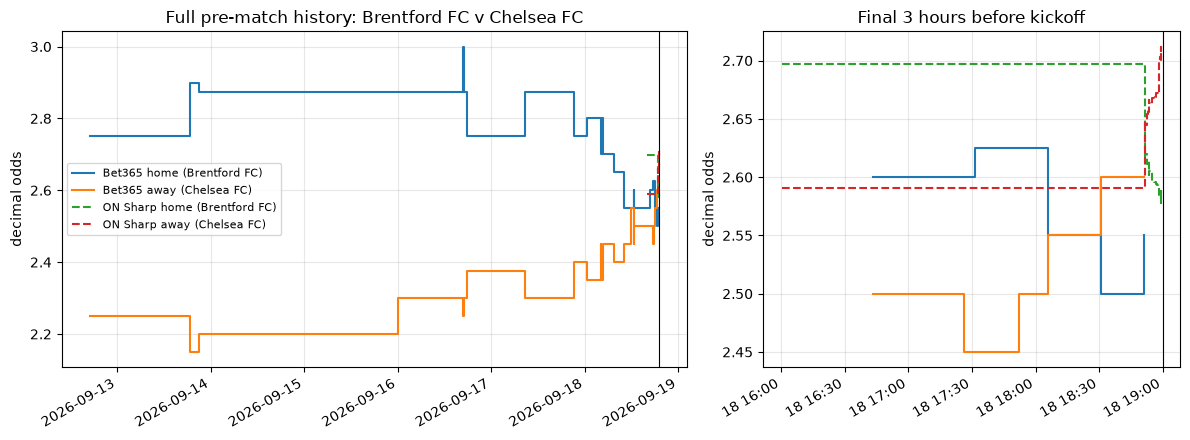

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={"width_ratios": [3, 2]})
for ax, window in [(ax1, None), (ax2, pd.Timedelta(hours=3))]:
    for book, d, style in [("Bet365", b365, "-"), (SHARP, sharp, "--")]:
        if window is not None:
            d = d[d["time"] >= kick - window]
        if d.empty:
            continue
        ax.step(d["time"], d["home"], where="post", linestyle=style, label=f"{book} home ({mv['home']})")
        ax.step(d["time"], d["away"], where="post", linestyle=style, label=f"{book} away ({mv['away']})")
    ax.axvline(kick, color="black", linewidth=0.8)
    ax.set_ylabel("decimal odds")
    ax.grid(alpha=0.3)
ax1.set_title(f"Full pre-match history: {mv['home']} v {mv['away']}")
ax2.set_title("Final 3 hours before kickoff")
ax1.legend(fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Notes

* Market names in v3 are `ML`, `Spread` and `Totals` (plus `HT`, `2H` and prop variants). There is no "Match Winner" or "Over/Under".
* `hdp` on a Spread is signed from the home team's perspective: `hdp = -1.5` with `home = 5.90` is the home side giving 1.5 goals at 5.90.
* `updatedAt` on a market is the time of the last price change, not the last time the bookmaker was polled. A price that has not moved keeps its old timestamp.
* The free tier allows 100 requests per hour and restricts which bookmakers a key can request; the live path above uses nine requests and falls back to the frozen snapshot if a call is refused.
* `/historical/closing-lines` and `/odds/movements` are the two endpoints that make CLV tracking possible without running your own collector: the first gives closing prices with results for a whole league and date range, the second gives the full price path for one market.

## Data source

Prices, closing lines and movements come from the [Odds-API.io](https://odds-api.io) v3 REST API. The [value bets guide](https://docs.odds-api.io/guides/value-bets) documents the endpoint parameters used here, and the [value bets and CLV Python tutorial](https://odds-api.io/blog/value-bets-clv-python-tutorial) walks through the same devigging maths in more depth. The frozen snapshot in `data/snapshot-2026-09-19.json` was captured on 18 September 2026 at the time printed in section 1; `source=live` in that output means the cells ran against the API instead.